# Simple Attention (Without Trainable Weights)

Your journey starts with one step

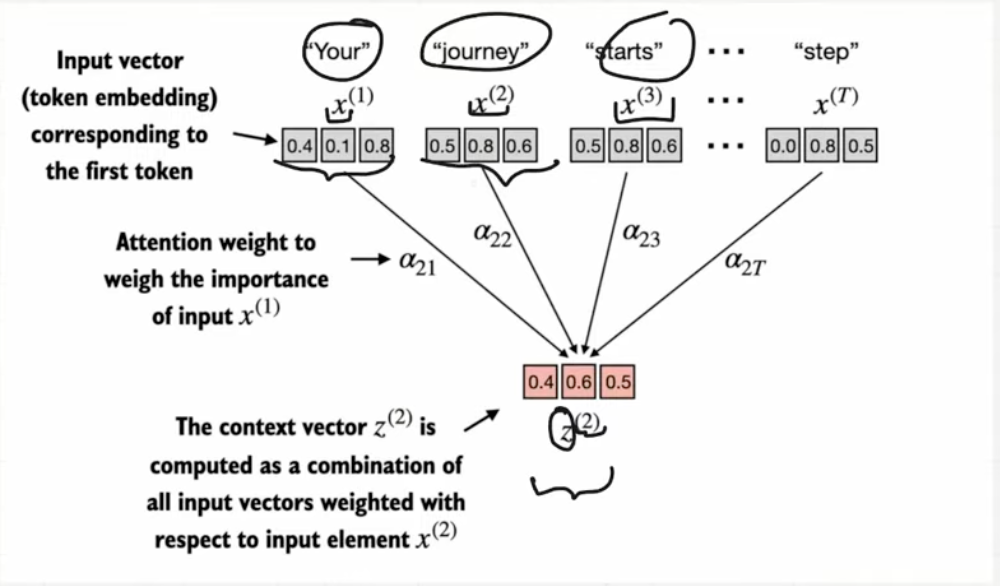

Goal of self attention - Calculate a context vector z<sup>(i)</sup> for each element x<sup>(i)<sup>

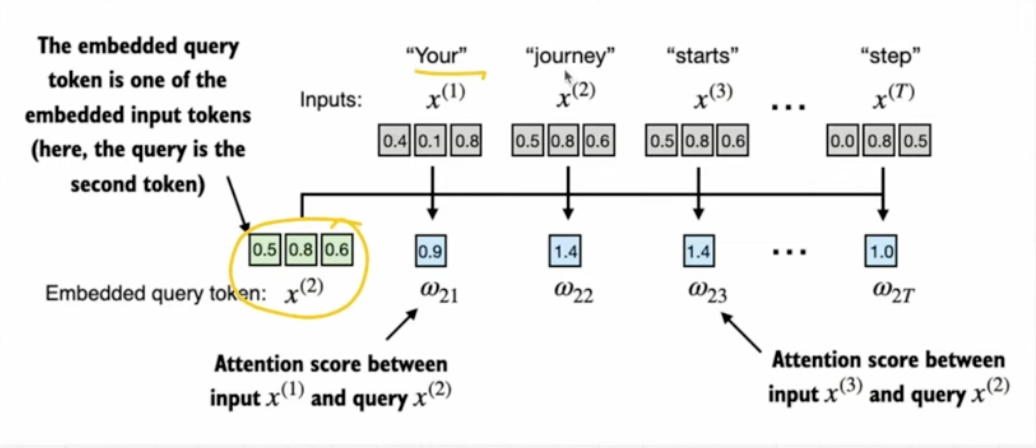

In [1]:
import torch

inputs = torch.tensor(
    [[0.43, 0.15, 0.89],  # Your      (x^1)
     [0.55, 0.87, 0.66],  # journey   (x^2)
     [0.57, 0.85, 0.64],  # starts    (x^3)
     [0.22, 0.58, 0.33],  # with      (x^4)
     [0.77, 0.25, 0.10],  # one       (x^5)
     [0.05, 0.80, 0.55]]  # step      (x^6)
)

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

words = ['Your','jounery','starts','with','one','step']

x_coords = inputs[:,0].numpy()
y_coords = inputs[:,1].numpy()
z_coords = inputs[:,2].numpy()

## Dot product as Similarity Measure

In [3]:
query = inputs[1]

attn_scores_2 = torch.empty(inputs.shape[0])
for i,x_i in enumerate(inputs):
    attn_scores_2[i]= torch.dot(x_i, query)
    
print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


## Normalization

We need normalization for interpretability. The gold behind normalization is to obtain weights that sum upto 1. This helps for easy interpretationa dn maintaining training stability in an LLM.

### Sum Normalization

In [4]:
attn_weights_2_tmp = attn_scores_2/attn_scores_2.sum()
print("Attention Weights:" , attn_weights_2_tmp)
print("Sum:", attn_weights_2_tmp.sum())

Attention Weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)


Why this fails??

1. Suppose we have [1, 2, 3, 400] then after normalization we have 
- [1/406,2/406,3/406,400/406] ~ [0.00246, 0.00493,0.00739,0.985]
But ideally, we want [0, 0, 0, 1] otherwise while training, model slightly gives weightage to these smaller values and optimizer may not work

2. If we have negative values like [-1,2, 4,6] -> [-1/11, 2/11, 4/11, 6/11]. This negativity makes interpretability harder

### Softmax Normalization

1. [x1,x2,x3...,xn] -> [e<sup>x1</sup>,e<sup>x2</sup>,....,e<sup>xn</sup>] -> Then do above sum normalization on these exponentiated values

2. What pythorch does
[x1,x2,x3...,xn] -> [e<sup>x1-max</sup>,e<sup>x2-max</sup>,....,e<sup>xn-max</sup>]-> Then do above sum normalization on these exponentiated values. This is done to prevent overflowing

In [5]:
## Naive softmax
def softmax_naive(x):
    return torch.exp(x)/torch.exp(x).sum(dim=0)

attn_weights_2_naive = softmax_naive(attn_scores_2)

print("Attention weights:", attn_weights_2_naive)
print("Sum:", attn_weights_2_naive.sum())


Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


In [6]:
## Pytorch softmax (advisable to use)
attn_weights_2 = torch.softmax(attn_scores_2,dim=0)
print("Attention weights:", attn_weights_2)
print("Sum:", attn_weights_2.sum())


Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


## Find the context vector

After computing the normalized attention weights, we calculate the context vector z<sup>2</sup> by mutiplying the embedded input tokens x<sup>(i)</sup>, with the corresponding attention weights and then summing the resultant vectors

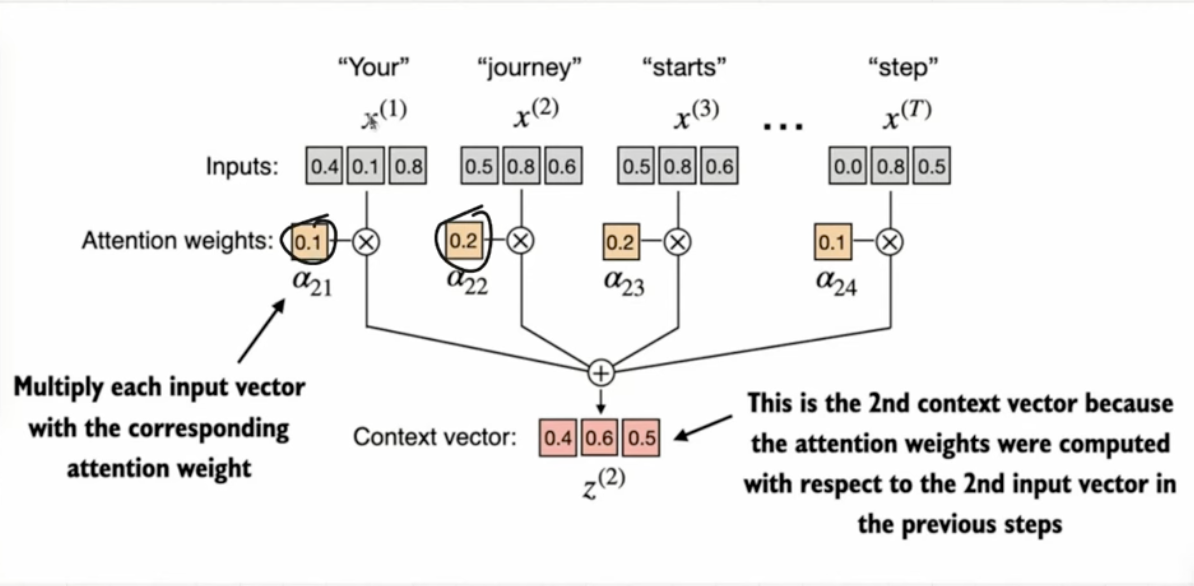
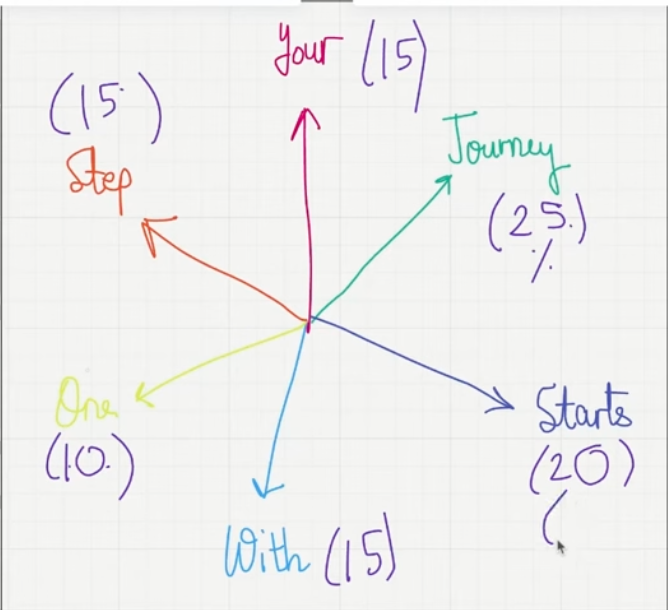

In [7]:
query = inputs[1] #2nd input token in query
context_vec_2 = torch.zeros(query.shape)
for i,x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i]*x_i
    
print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


## Extending to all inputs

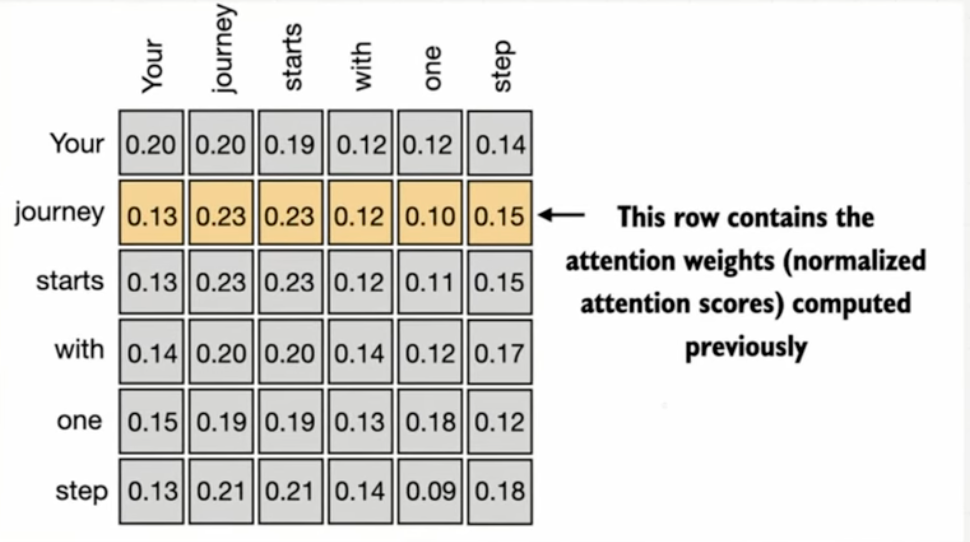

In [8]:
## Steps involved
# 1. Compute attention scores
# 2. Compute attention weights
# 3. Compute context vectors

In [9]:
"""
Naive approach - 

attn_scores = torch.empty(6,6)
for i,x_i in enumerate(inputs):
    for j,x_j in enumerate(inputs):
        attn_scores[i,j] = torch.dot(x_i,x_j)

"""

attention_scores = inputs @ inputs.T
print(attention_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [10]:
## check about the dim parameter, It specifies dimension of input tensor along which we need to apply the computation
## By setting dim=-1, we are instructing the softmax function to apply 
# the normalization along the last dimension of the attn_scores tensor.

attention_weights = torch.softmax(attention_scores,dim=-1)
print(attention_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [11]:
context_vectors = attention_weights @ inputs
print(context_vectors)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


## What is wrong in this ??


We are not using context in any way, we are just using their initial vector. Lets consider a simple sentence:

Sentence : "The cat sat on the mat because it was warm".
Query : "warm"

- without trainable weights: If we only use the dot product between the query "warm" and each word's embedding, we might find that "warm" is most similar to itself, and maybe somewhat related to "mat" (if our embeddings capture that mats can be warm). Words like "The", "cat", "sat" might have low similarity scores because they are not semantically related to "warm"

- with trainable weights: the madel can learn that "warm" hould pay more attention to "mat" even if "mat" is not semantically similar to "warm" in a traditional embedding space. The model learns that "warm" often follows "mat" in contexts like this one, capturing the long-range dependency
